# TASK 3 HEART DISEASE UCI DATASET

# Step 1: Load and Inspect Dataset

In [16]:
import pandas as pd

# Load dataset

df = pd.read_csv("C:/Users/Hp/Desktop/heart_disease_uci.csv")  # Replace with actual file path if needed
# Preview the first few rows of the data
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Step 2: Clean the Dataset (Handle Missing Values)

In [18]:

from sklearn.impute import SimpleImputer

# Optional: Drop high-missing-value columns if needed (like 'ca', 'thal')
df = df.drop(columns=['ca', 'thal'], errors='ignore')

# Encode any categorical features if needed
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Impute missing values with mean strategy
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


# Step 3: Perform EDA (Exploratory Data Analysis)

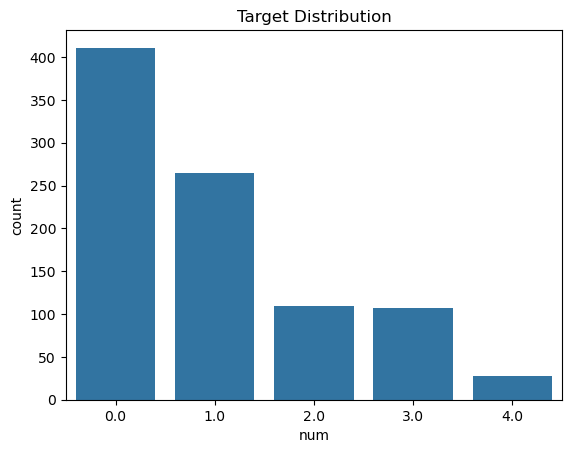

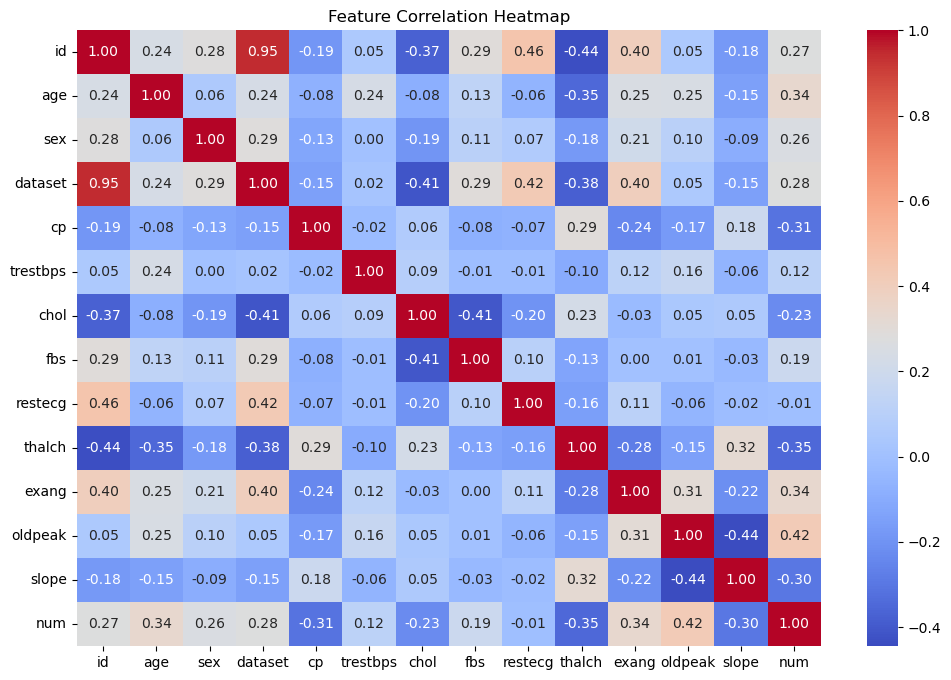

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class distribution
sns.countplot(x='num', data=df_imputed)
plt.title('Target Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_imputed.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# Step 4: Prepare Data for Training

In [20]:
from sklearn.model_selection import train_test_split

# Convert 'num' to binary classification (0 = no disease, 1 = disease)
df_imputed['target'] = (df_imputed['num'] > 0).astype(int)

# Define features and target
X = df_imputed.drop(columns=['id', 'num'], errors='ignore')
y = df_imputed['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


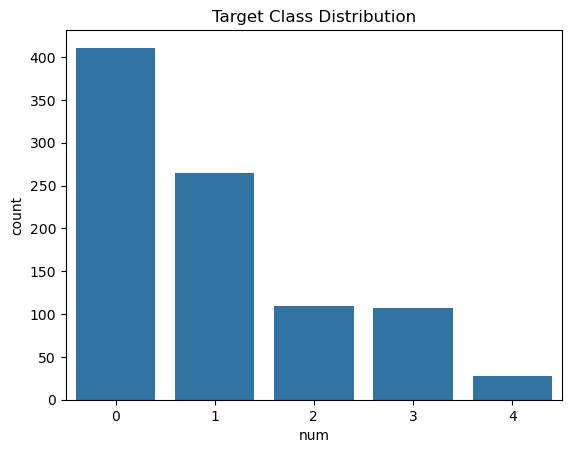

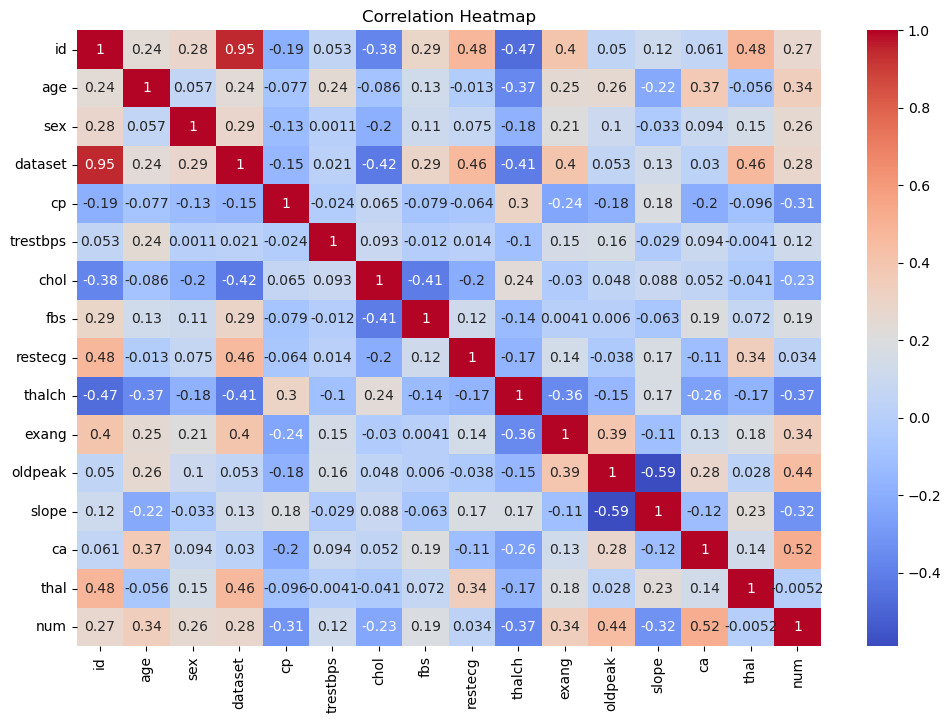

In [7]:
# Class balance
sns.countplot(data=df, x='num')
plt.title('Target Class Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Step 5: Train the Model (Logistic Regression)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

# Step 6: Evaluate the Model

Accuracy: 1.0
Confusion Matrix:
 [[ 75   0]
 [  0 109]]
ROC AUC: 1.0


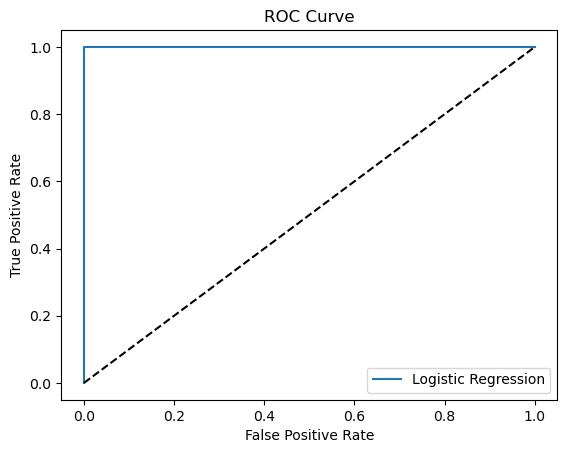

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC Score
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Step 7: Highlight Important Features (Feature Importance)

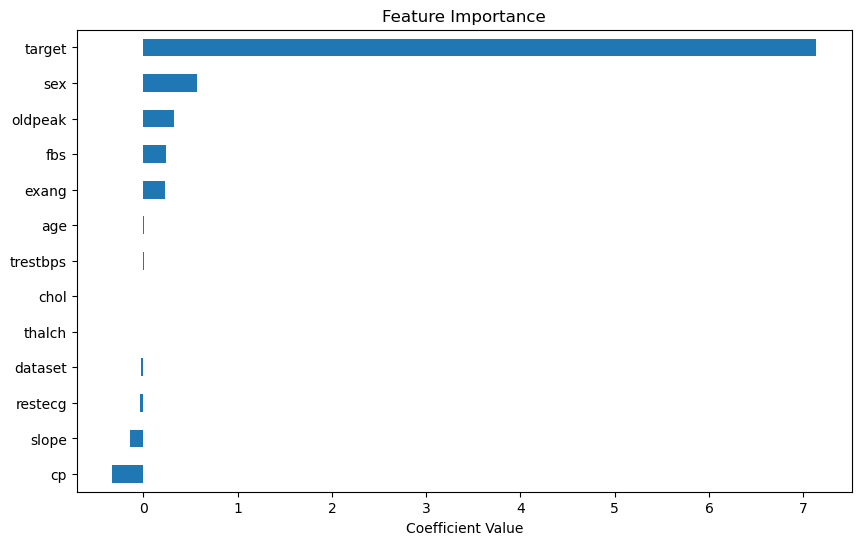

In [23]:
# Logistic Regression Coefficients as feature importance
import numpy as np
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title='Feature Importance')
plt.xlabel("Coefficient Value")
plt.show()
